In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt
TRAIN_IMAGES_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte"
TRAIN_LABELS_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte"
TEST_IMAGES_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte"
TEST_LABELS_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte"

def load_images(file_path):
    with open(file_path, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
        images = images.astype(np.float32) / 255.0
    return images

def load_labels(file_path):
    with open(file_path, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

X_train = load_images(TRAIN_IMAGES_PATH)
X_test = load_images(TEST_IMAGES_PATH)
y_train = load_labels(TRAIN_LABELS_PATH)
y_test = load_labels(TEST_LABELS_PATH)

input_size = 784
hidden1_size = 256
latent_size = 64
hidden2_size = 256
output_size = 784

# DENSE AE

This autoencoder uses a fully connected architecture:

784 → 256 (ReLU) → 64 (bottleneck) → 256 (ReLU) → 784 (sigmoid output).

There is no activation on the latent layer itself which keeps the bottleneck from clipping information the way ReLU would.

I used the Adam optimizer because it automatically adjusts the learning rate for each parameter during training. Since my autoencoder has multiple layers with different weight matrix sizes, using normal gradient descent would require a lot of manual tuning of the learning rate. Adam made training faster, more stable, and helped the model converge better using a single learning rate.

In [ ]:
def initialize_parameters():
    W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
    b1 = np.zeros((1, hidden1_size))

    W2 = np.random.randn(hidden1_size, latent_size) * np.sqrt(2 / hidden1_size)
    b2 = np.zeros((1, latent_size))

    W3 = np.random.randn(latent_size, hidden2_size) * np.sqrt(2 / latent_size)
    b3 = np.zeros((1, hidden2_size))

    W4 = np.random.randn(hidden2_size, output_size) * np.sqrt(1/hidden2_size)
    b4 = np.zeros((1, output_size))
    return W1, b1, W2, b2, W3, b3, W4, b4

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(np.float32)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def compute_loss(original, reconstructed):
    loss = np.mean((original - reconstructed) ** 2)
    return loss

def mse_derivative(original, reconstructed):
    m = original.shape[0]
    return (2 * (reconstructed - original)) / m

In [ ]:
def forward(X, W1, b1, W2, b2, W3, b3, W4, b4):
    #encoder
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = Z2   # Latent Vector, no activation so no data loss happens at latent vector

    #decoder
    Z3 = np.dot(A2, W3) + b3
    A3 = relu(Z3)

    Z4 = np.dot(A3, W4) + b4
    A4 = sigmoid(Z4)

    cache = X, Z1, A1, Z2, A2, Z3, A3, Z4, A4
    return A4, cache

def backward(cache, W1, W2, W3, W4):
    X, Z1, A1, Z2, A2, Z3, A3, Z4, A4 = cache
    m = X.shape[0]

    #output Layer
    dA4 = mse_derivative(X, A4)
    dZ4 = dA4 * sigmoid_derivative(A4)
    dW4 = np.dot(A3.T, dZ4)
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    # hidden layer 3
    dA3 = np.dot(dZ4, W4.T)
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # latent layer
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # hidden layer 1
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = dW1, db1, dW2, db2, dW3, db3, dW4, db4
    return gradients

def init_adam_state(param):
    return {'m': np.zeros_like(param), 'v': np.zeros_like(param)}

def adam_update(param, grad, state, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    state['m'] = beta1 * state['m'] + (1 - beta1) * grad
    state['v'] = beta2 * state['v'] + (1 - beta2) * (grad ** 2)
    m_hat = state['m'] / (1 - beta1 ** t)
    v_hat = state['v'] / (1 - beta2 ** t)
    param = param - lr * m_hat / (np.sqrt(v_hat) + eps)
    return param, state

def update_parameters_adam(W1, b1, W2, b2, W3, b3, W4, b4, gradients, adam_states, t, lr):
    dW1, db1, dW2, db2, dW3, db3, dW4, db4 = gradients

    W1, adam_states['W1'] = adam_update(W1, dW1, adam_states['W1'], t, lr)
    b1, adam_states['b1'] = adam_update(b1, db1, adam_states['b1'], t, lr)
    W2, adam_states['W2'] = adam_update(W2, dW2, adam_states['W2'], t, lr)
    b2, adam_states['b2'] = adam_update(b2, db2, adam_states['b2'], t, lr)
    W3, adam_states['W3'] = adam_update(W3, dW3, adam_states['W3'], t, lr)
    b3, adam_states['b3'] = adam_update(b3, db3, adam_states['b3'], t, lr)
    W4, adam_states['W4'] = adam_update(W4, dW4, adam_states['W4'], t, lr)
    b4, adam_states['b4'] = adam_update(b4, db4, adam_states['b4'], t, lr)

    return W1, b1, W2, b2, W3, b3, W4, b4, adam_states

def update_parameters( W1, b1, W2, b2, W3, b3, W4, b4, gradients, learning_rate):
    dW1, db1, dW2, db2, dW3, db3, dW4, db4 = gradients

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W4 -= learning_rate * dW4
    b4 -= learning_rate * db4

    return W1, b1, W2, b2, W3, b3, W4, b4

In [ ]:
epochs = 50
batch_size = 128
learning_rate = 0.001
num_samples = X_train.shape[0]
loss_history = []
t = 0

W1, b1, W2, b2, W3, b3, W4, b4 = initialize_parameters()

adam_states = {
    'W1': init_adam_state(W1), 'b1': init_adam_state(b1),
    'W2': init_adam_state(W2), 'b2': init_adam_state(b2),
    'W3': init_adam_state(W3), 'b3': init_adam_state(b3),
    'W4': init_adam_state(W4), 'b4': init_adam_state(b4),
}
for epoch in range(epochs):
    # shuffle the training data
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    epoch_loss = 0

    # mini-batches
    for i in range(0, num_samples, batch_size):
        batch = X_shuffled[i:i + batch_size]
        #forward
        reconstructed, cache = forward(batch, W1, b1, W2, b2, W3, b3, W4, b4)
        #loss
        loss = compute_loss(batch, reconstructed)
        epoch_loss += loss
        gradients = backward(cache, W1, W2, W3, W4)
        #backward
        t += 1
        W1, b1, W2, b2, W3, b3, W4, b4, adam_states = update_parameters_adam( W1, b1, W2, b2, W3, b3, W4, b4, gradients, adam_states, t, learning_rate)

    epoch_loss /= (num_samples // batch_size)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{epochs}  Loss = {epoch_loss:.6f}")

Epoch  1/50  Loss = 0.029399
Epoch  2/50  Loss = 0.014702
Epoch  3/50  Loss = 0.012593
Epoch  4/50  Loss = 0.011627
Epoch  5/50  Loss = 0.010997
Epoch  6/50  Loss = 0.010614
Epoch  7/50  Loss = 0.010393
Epoch  8/50  Loss = 0.010152
Epoch  9/50  Loss = 0.010011
Epoch 10/50  Loss = 0.009860
Epoch 11/50  Loss = 0.009789
Epoch 12/50  Loss = 0.009739
Epoch 13/50  Loss = 0.009678
Epoch 14/50  Loss = 0.009654
Epoch 15/50  Loss = 0.009613
Epoch 16/50  Loss = 0.009558
Epoch 17/50  Loss = 0.009633
Epoch 18/50  Loss = 0.009468
Epoch 19/50  Loss = 0.009485
Epoch 20/50  Loss = 0.009474
Epoch 21/50  Loss = 0.009424
Epoch 22/50  Loss = 0.009438
Epoch 23/50  Loss = 0.009428
Epoch 24/50  Loss = 0.009341
Epoch 25/50  Loss = 0.009353
Epoch 26/50  Loss = 0.009359
Epoch 27/50  Loss = 0.009364
Epoch 28/50  Loss = 0.009253
Epoch 29/50  Loss = 0.009236
Epoch 30/50  Loss = 0.009387
Epoch 31/50  Loss = 0.009270
Epoch 32/50  Loss = 0.009258
Epoch 33/50  Loss = 0.009250
Epoch 34/50  Loss = 0.009259
Epoch 35/50  L

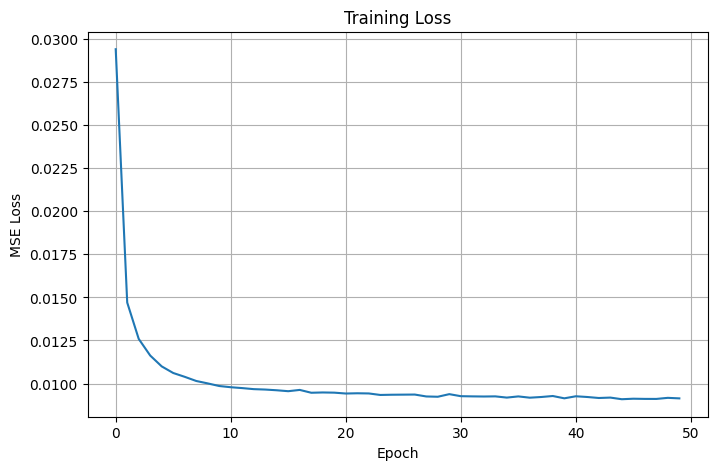

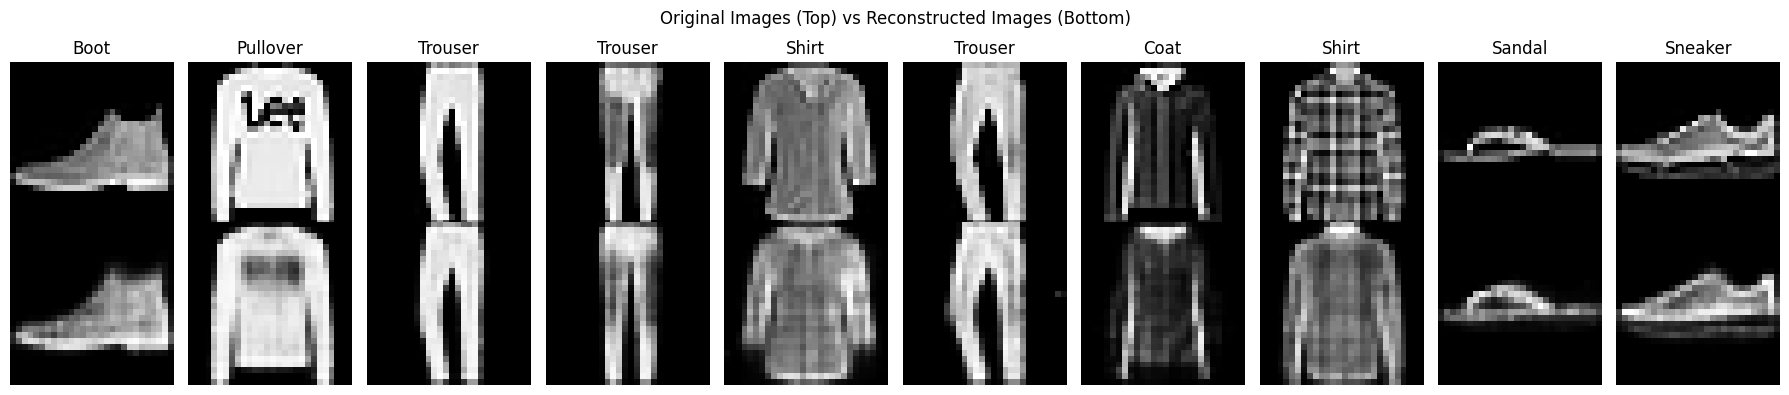

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

def reconstruct(images):
    reconstructed, _ = forward(images, W1, b1, W2, b2,W3, b3,W4, b4)
    return reconstructed

sample_images = X_test[:10]
reconstructed_images = reconstruct(sample_images)

fashion_labels = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Boot"]
n = 10
plt.figure(figsize=(18,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap="gray")
    plt.title(fashion_labels[y_test[i]])
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images (Top) vs Reconstructed Images (Bottom)")
plt.tight_layout()
plt.show()

# CONV AE
The encoder uses two 3×3 convolution layers with ReLU activation. The first layer increases the channels from 1 to 8, and the second from 8 to 16. After each convolution, a 2×2 max-pooling layer reduces the image size, so the input changes from 28×28 → 14×14 → 7×7. The final 7×7×16 feature maps are flattened and compressed into a 64-dimensional latent vector using a fully connected layer. This also uses the Adams optimizer.

Although this is a convolutional autoencoder, it still uses fully connected layers at the bottleneck to compress the feature maps into a 64-dimensional latent vector. Therefore, the model combines convolutional feature extraction with a dense bottleneck, rather than being a completely convolution-only architecture. This allows it to learn useful image features while still performing dimensionality reduction.

In [ ]:
def im2col_batch(input_maps, f_h, f_w):
    # input_maps: (batch, C, H, W)  ->  cols: (batch, C*f_h*f_w, out_h*out_w)
    batch, C, H, W = input_maps.shape
    out_h = H - f_h + 1
    out_w = W - f_w + 1

    s0, s1, s2, s3 = input_maps.strides
    shape = (batch, C, out_h, out_w, f_h, f_w)
    strides = (s0, s1, s2, s3, s2, s3)
    patches = np.lib.stride_tricks.as_strided(input_maps, shape=shape, strides=strides)

    patches = patches.transpose(0, 1, 4, 5, 2, 3)
    cols = patches.reshape(batch, C * f_h * f_w, out_h * out_w)
    return cols, out_h, out_w

def col2im_batch(d_cols, input_shape, f_h, f_w):
    # d_cols: (batch, C*f_h*f_w, out_h*out_w)  ->  d_input: (batch, C, H, W)
    batch, C, H, W = input_shape
    out_h = H - f_h + 1
    out_w = W - f_w + 1

    d_input = np.zeros((batch, C, H, W))
    d_cols_r = d_cols.reshape(batch, C, f_h, f_w, out_h, out_w)

    for di in range(f_h):
        for dj in range(f_w):
            d_input[:, :, di:di+out_h, dj:dj+out_w] += d_cols_r[:, :, di, dj, :, :]

    return d_input

def conv_multichannel(input_maps, filters, biases):
    # input_maps: (batch, C, H, W), filters: (num_filters, C, f_h, f_w)
    num_filters, in_channels, f_h, f_w = filters.shape

    cols, out_h, out_w = im2col_batch(input_maps, f_h, f_w)
    filters_flat = filters.reshape(num_filters, -1)

    output = np.einsum('fk,bkp->bfp', filters_flat, cols)
    output = output.reshape(-1, num_filters, out_h, out_w)
    output += biases.reshape(1, num_filters, 1, 1)

    return output

def conv_multichannel_backward(d_out, input_maps, filters):
    # d_out: (batch, num_filters, out_h, out_w), input_maps: (batch, C, H, W)
    num_filters, in_channels, f_h, f_w = filters.shape
    batch, C, H, W = input_maps.shape

    cols, out_h, out_w = im2col_batch(input_maps, f_h, f_w)
    filters_flat = filters.reshape(num_filters, -1)
    d_out_flat = d_out.reshape(batch, num_filters, out_h * out_w)

    # gradient w.r.t filters summed across the whole batch, like grads_sum used to be
    d_filters_flat = np.einsum('bfp,bkp->fk', d_out_flat, cols)
    d_filters = d_filters_flat.reshape(num_filters, in_channels, f_h, f_w)

    d_biases = d_out.sum(axis=(0, 2, 3))

    d_cols = np.einsum('fk,bfp->bkp', filters_flat, d_out_flat)
    d_input = col2im_batch(d_cols, (batch, C, H, W), f_h, f_w)

    return d_filters, d_biases, d_input

def maxpool_multi_forward(feature_maps, size=2, stride=2):
    # feature_maps: (batch, C, H, W)
    batch, C, H, W = feature_maps.shape
    out_h = (H - size) // stride + 1
    out_w = (W - size) // stride + 1

    s0, s1, s2, s3 = feature_maps.strides
    shape = (batch, C, out_h, out_w, size, size)
    strides = (s0, s1, s2 * stride, s3 * stride, s2, s3)
    windows = np.lib.stride_tricks.as_strided(feature_maps, shape=shape, strides=strides)
    windows = windows.reshape(batch, C, out_h, out_w, size * size)

    output = windows.max(axis=-1)
    max_idx = windows.argmax(axis=-1)   # (batch, C, out_h, out_w), flat index into window

    return output, max_idx

def maxpool_multi_backward(d_out, feature_maps_shape, max_idx, size=2, stride=2):
    batch, C, H, W = feature_maps_shape
    out_h, out_w = d_out.shape[2], d_out.shape[3]

    d_feature_maps = np.zeros((batch, C, H, W))

    di = max_idx // size
    dj = max_idx % size

    b_idx = np.arange(batch).reshape(batch, 1, 1, 1)
    c_idx = np.arange(C).reshape(1, C, 1, 1)
    i_idx = np.arange(out_h).reshape(1, 1, out_h, 1)
    j_idx = np.arange(out_w).reshape(1, 1, 1, out_w)

    row = i_idx * stride + di
    col = j_idx * stride + dj

    np.add.at(d_feature_maps, (b_idx, c_idx, row, col), d_out)

    return d_feature_maps

def conv_same_forward(x, filters, biases):
    k = filters.shape[2]
    p = (k - 1) // 2
    x_padded = np.pad(x, ((0,0),(0,0),(p,p),(p,p)))
    out = conv_multichannel(x_padded, filters, biases)
    return out, x_padded

def conv_same_backward(d_out, x_padded, filters, orig_H, orig_W):
    d_filters, d_biases, d_input_padded = conv_multichannel_backward(d_out, x_padded, filters)
    k = filters.shape[2]
    p = (k - 1) // 2
    d_input = d_input_padded[:, :, p:p+orig_H, p:p+orig_W] if p > 0 else d_input_padded
    return d_filters, d_biases, d_input

def upsample_nearest_forward(x, scale=2):
    return np.repeat(np.repeat(x, scale, axis=2), scale, axis=3)

def upsample_nearest_backward(d_out, scale=2):
    b, c, h, w = d_out.shape
    h_in, w_in = h // scale, w // scale
    d_out_r = d_out.reshape(b, c, h_in, scale, w_in, scale)
    return d_out_r.sum(axis=(3, 5))

def initialize_conv_ae_params(latent_size=64):
    def conv_init(out_c, in_c, k):
        return np.random.randn(out_c, in_c, k, k) * np.sqrt(2 / (in_c*k*k))

    filters1, biases1 = conv_init(8, 1, 3), np.zeros(8)     # encoder conv 1
    filters2, biases2 = conv_init(16, 8, 3), np.zeros(16)   # encoder conv 2
    filters3, biases3 = conv_init(8, 16, 3), np.zeros(8)    # decoder conv 1
    filters4, biases4 = conv_init(1, 8, 3), np.zeros(1)     # decoder conv 2 (output)

    flat_size = 16 * 7 * 7
    W_enc = np.random.randn(flat_size, latent_size) * np.sqrt(2/flat_size)
    b_enc = np.zeros((1, latent_size))
    W_dec = np.random.randn(latent_size, flat_size) * np.sqrt(2/latent_size)
    b_dec = np.zeros((1, flat_size))

    return {"filters1": filters1, "biases1": biases1, "filters2": filters2, "biases2": biases2,
            "filters3": filters3, "biases3": biases3, "filters4": filters4, "biases4": biases4,
            "W_enc": W_enc, "b_enc": b_enc, "W_dec": W_dec, "b_dec": b_dec}

def conv_ae_forward(images, params):
    batch = images.shape[0]
    X = images.reshape(batch, 1, 28, 28)

    # encoder
    Z1, pad1 = conv_same_forward(X, params["filters1"], params["biases1"])
    A1 = relu(Z1)
    P1, pos1 = maxpool_multi_forward(A1, 2, 2)          # -> 14x14

    Z2, pad2 = conv_same_forward(P1, params["filters2"], params["biases2"])
    A2 = relu(Z2)
    P2, pos2 = maxpool_multi_forward(A2, 2, 2)          # -> 7x7

    flat = P2.reshape(batch, -1)
    latent = flat @ params["W_enc"] + params["b_enc"]  # linear bottleneck (no ReLU)

    # decoder
    flat_dec_pre = latent @ params["W_dec"] + params["b_dec"]
    A_dec = relu(flat_dec_pre)
    P_dec = A_dec.reshape(batch, 16, 7, 7)

    U1 = upsample_nearest_forward(P_dec, 2)             # -> 14x14
    Z3, pad3 = conv_same_forward(U1, params["filters3"], params["biases3"])
    A3 = relu(Z3)

    U2 = upsample_nearest_forward(A3, 2)    # -> 28x28
    Z4, pad4 = conv_same_forward(U2, params["filters4"], params["biases4"])
    output = sigmoid(Z4)

    cache = {"pad1": pad1, "Z1": Z1, "A1": A1, "pos1": pos1,
             "pad2": pad2, "Z2": Z2, "A2": A2, "pos2": pos2,
             "flat": flat, "latent": latent, "flat_dec_pre": flat_dec_pre,
             "pad3": pad3, "Z3": Z3,
             "pad4": pad4, "output": output}
    return output.reshape(batch, -1), cache

def conv_ae_backward(images, cache, params):
    batch = images.shape[0]
    X_true = images.reshape(batch, 1, 28, 28)
    output = cache["output"]

    dA4 = mse_derivative(X_true, output)
    dZ4 = dA4 * sigmoid_derivative(output)
    d_filters4, d_biases4, dU2 = conv_same_backward(dZ4, cache["pad4"], params["filters4"], 28, 28)

    dA3 = upsample_nearest_backward(dU2, 2)
    dZ3 = dA3 * relu_derivative(cache["Z3"])
    d_filters3, d_biases3, dU1 = conv_same_backward(dZ3, cache["pad3"], params["filters3"], 14, 14)

    dP_dec = upsample_nearest_backward(dU1, 2)
    dA_dec = dP_dec.reshape(batch, -1)
    dZ_dec = dA_dec * relu_derivative(cache["flat_dec_pre"])
    dW_dec = cache["latent"].T @ dZ_dec
    db_dec = dZ_dec.sum(axis=0, keepdims=True)
    dlatent = dZ_dec @ params["W_dec"].T

    dW_enc = cache["flat"].T @ dlatent
    db_enc = dlatent.sum(axis=0, keepdims=True)
    dflat = dlatent @ params["W_enc"].T

    dP2 = dflat.reshape(batch, 16, 7, 7)
    dA2 = maxpool_multi_backward(dP2, cache["A2"].shape, cache["pos2"], 2, 2)
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    d_filters2, d_biases2, dP1 = conv_same_backward(dZ2, cache["pad2"], params["filters2"], 14, 14)

    dA1 = maxpool_multi_backward(dP1, cache["A1"].shape, cache["pos1"], 2, 2)
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    d_filters1, d_biases1, _ = conv_same_backward(dZ1, cache["pad1"], params["filters1"], 28, 28)

    return {"filters1": d_filters1, "biases1": d_biases1, "filters2": d_filters2, "biases2": d_biases2, "filters3": d_filters3, "biases3": d_biases3, "filters4": d_filters4, "biases4": d_biases4, "W_enc": dW_enc, "b_enc": db_enc, "W_dec": dW_dec, "b_dec": db_dec}

In [ ]:
#training loop:
params = initialize_conv_ae_params(latent_size=64)
adam_states = {k: init_adam_state(v) for k, v in params.items()}

epochs = 10
batch_size = 128
learning_rate = 0.001
num_samples = X_train.shape[0]
loss_history = []
t = 0
# X_train_small = X_train[:10000]

for epoch in range(epochs):
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    epoch_loss = 0

    for i in range(0, num_samples, batch_size):
        batch = X_shuffled[i:i+batch_size]

        reconstructed, cache = conv_ae_forward(batch, params)
        loss = compute_loss(batch, reconstructed)
        epoch_loss += loss

        grads = conv_ae_backward(batch, cache, params)

        t += 1
        for key in params:
            params[key], adam_states[key] = adam_update(params[key], grads[key], adam_states[key], t, learning_rate)

    epoch_loss /= (num_samples // batch_size)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{epochs}  Loss = {epoch_loss:.6f}")

Epoch  1/10  Loss = 0.026425
Epoch  2/10  Loss = 0.015246
Epoch  3/10  Loss = 0.013153
Epoch  4/10  Loss = 0.011983
Epoch  5/10  Loss = 0.011200
Epoch  6/10  Loss = 0.010625
Epoch  7/10  Loss = 0.010180
Epoch  8/10  Loss = 0.009808
Epoch  9/10  Loss = 0.009504
Epoch 10/10  Loss = 0.009237


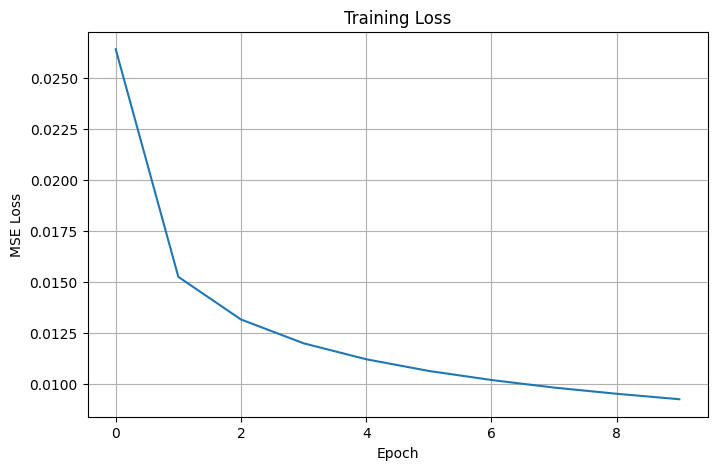

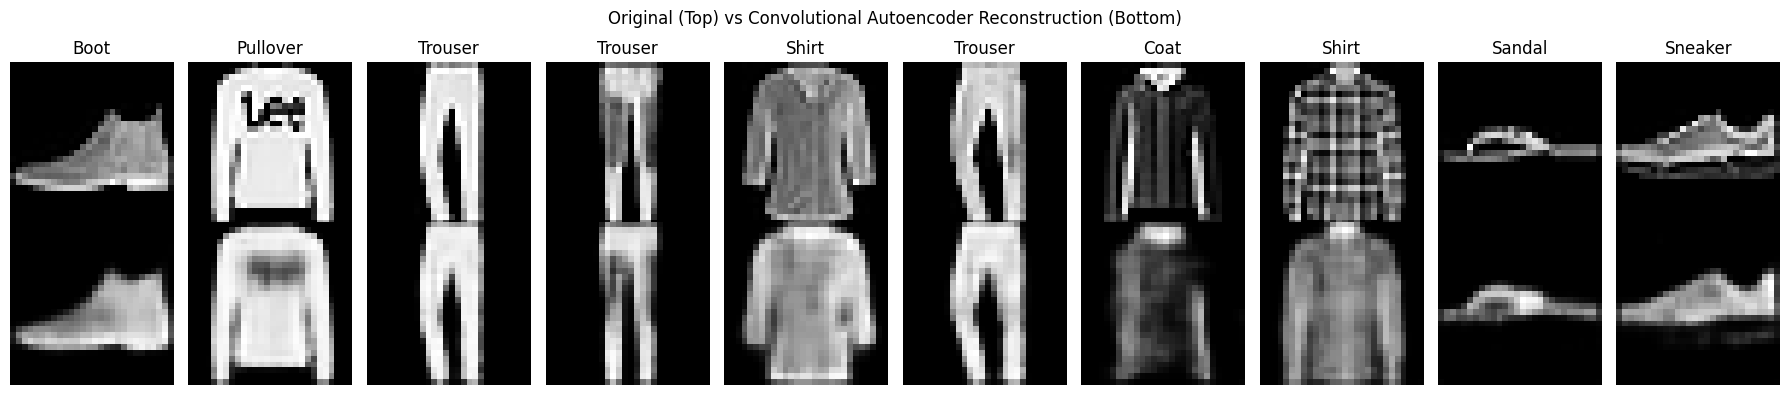

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

sample_images = X_test[:10]
reconstructed_images, _ = conv_ae_forward(sample_images, params)
fashion_labels = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Boot"]

plt.figure(figsize=(18,4))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap="gray")
    plt.title(fashion_labels[y_test[i]])
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original (Top) vs Convolutional Autoencoder Reconstruction (Bottom)")
plt.tight_layout()
plt.show()


# SPARSE AE

The sparse autoencoder uses the same network architecture as the dense autoencoder, which is 784 → 256 → 64 → 256 → 784 and all hidden layers use the relu activation function, and the output layer uses sigmoid so that the reconstructed pixel values stay between 0 and 1.

Unlike the dense autoencoder, this model encourages the latent layer to use only a few neurons at a time. To achieve this, an L1 sparsity penalty is added to the reconstruction loss. The total loss is calculated as: Total Loss = Reconstruction Loss + Sparsity Weight × L1 Penalty

The L1 penalty pushes most of the latent activations towards zero, so the network learns a more compact and efficient representation of the input instead of activating all latent neurons.

The main difference between the dense and sparse autoencoder is the additional sparsity penalty. While the dense autoencoder tries to reconstruct the input as accurately as possible, the sparse autoencoder also learns to represent the input using only a small number of active neurons in the latent layer. This encourages the model to learn more meaningful and compact features.


In [ ]:
def initialize_sparse_ae_params(input_size=784, hidden_size=256, latent_size=128):
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, latent_size) * np.sqrt(2 / hidden_size)
    b2 = np.zeros((1, latent_size))
    W3 = np.random.randn(latent_size, hidden_size) * np.sqrt(2 / latent_size)
    b3 = np.zeros((1, hidden_size))
    W4 = np.random.randn(hidden_size, input_size) * np.sqrt(1 / hidden_size)
    b4 = np.zeros((1, input_size))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3, "W4": W4, "b4": b4}

def sparse_ae_forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2) # latent (sparsity penalty applied here)

    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = relu(Z3)
    Z4 = A3 @ params["W4"] + params["b4"]
    A4 = sigmoid(Z4)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3, "Z4": Z4, "A4": A4}
    return A4, cache

def compute_sparse_loss(original, reconstructed, latent, sparsity_weight=1e-4):
    recon_loss = np.mean((original - reconstructed) ** 2)
    sparsity_loss = sparsity_weight * np.mean(np.abs(latent))
    return recon_loss + sparsity_loss, recon_loss, sparsity_loss

def sparse_ae_backward(cache, params, sparsity_weight=1e-4):
    X, Z1, A1, Z2, A2, Z3, A3, Z4, A4 = ( cache["X"], cache["Z1"], cache["A1"], cache["Z2"], cache["A2"],
        cache["Z3"], cache["A3"], cache["Z4"], cache["A4"] )
    m = X.shape[0]

    # output layer
    dA4 = mse_derivative(X, A4)
    dZ4 = dA4 * sigmoid_derivative(A4)
    dW4 = A3.T @ dZ4
    db4 = dZ4.sum(axis=0, keepdims=True)

    # hidden layer 3
    dA3 = dZ4 @ params["W4"].T
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = A2.T @ dZ3
    db3 = dZ3.sum(axis=0, keepdims=True)

    # latent layer: reconstruction gradient + L1 sparsity gradient (sign of activation)
    dA2_recon = dZ3 @ params["W3"].T
    dA2_sparsity = (sparsity_weight / m) * np.sign(A2)
    dA2 = dA2_recon + dA2_sparsity
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    # hidden layer 1
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3, "W4": dW4, "b4": db4}

In [ ]:

params = initialize_sparse_ae_params(hidden_size=256, latent_size=64)
adam_states = {k: init_adam_state(v) for k, v in params.items()}

epochs = 50
batch_size = 128
learning_rate = 0.001
sparsity_weight = 1e-1
num_samples = X_train.shape[0]
loss_history = []
t = 0

for epoch in range(epochs):
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    epoch_loss = 0
    epoch_recon = 0
    epoch_sparsity = 0

    for i in range(0, num_samples, batch_size):
        batch = X_shuffled[i:i+batch_size]

        reconstructed, cache = sparse_ae_forward(batch, params)
        loss, recon_loss, sparsity_loss = compute_sparse_loss(
            batch, reconstructed, cache["A2"], sparsity_weight
        )
        epoch_loss += loss
        epoch_recon += recon_loss
        epoch_sparsity += sparsity_loss

        grads = sparse_ae_backward(cache, params, sparsity_weight)

        t += 1
        for key in params:
            params[key], adam_states[key] = adam_update(params[key], grads[key], adam_states[key], t, learning_rate)

    n_batches = num_samples // batch_size
    epoch_loss /= n_batches
    epoch_recon /= n_batches
    epoch_sparsity /= n_batches
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{epochs}  Loss={epoch_loss:.6f}  Recon={epoch_recon:.6f}  Sparsity={epoch_sparsity:.6f}")

Epoch  1/50  Loss=0.062396  Recon=0.030360  Sparsity=0.032036
Epoch  2/50  Loss=0.042761  Recon=0.016020  Sparsity=0.026742
Epoch  3/50  Loss=0.038768  Recon=0.014001  Sparsity=0.024768
Epoch  4/50  Loss=0.036275  Recon=0.012984  Sparsity=0.023291
Epoch  5/50  Loss=0.034434  Recon=0.012280  Sparsity=0.022154
Epoch  6/50  Loss=0.032840  Recon=0.011747  Sparsity=0.021093
Epoch  7/50  Loss=0.031454  Recon=0.011354  Sparsity=0.020100
Epoch  8/50  Loss=0.030239  Recon=0.011043  Sparsity=0.019196
Epoch  9/50  Loss=0.029136  Recon=0.010743  Sparsity=0.018393
Epoch 10/50  Loss=0.028197  Recon=0.010501  Sparsity=0.017697
Epoch 11/50  Loss=0.027368  Recon=0.010294  Sparsity=0.017074
Epoch 12/50  Loss=0.026648  Recon=0.010121  Sparsity=0.016527
Epoch 13/50  Loss=0.025987  Recon=0.009941  Sparsity=0.016045
Epoch 14/50  Loss=0.025383  Recon=0.009797  Sparsity=0.015586
Epoch 15/50  Loss=0.024858  Recon=0.009650  Sparsity=0.015208
Epoch 16/50  Loss=0.024366  Recon=0.009539  Sparsity=0.014827
Epoch 17

Loss      = Total Loss
Recon     = Reconstruction Loss (MSE)
Sparsity  = L1 Sparsity Penalty

During training, both the reconstruction loss and the sparsity loss decreased steadily, showing that the model learned to reconstruct the images more accurately and that the latent layer learned to use fewer and smaller activations. This shows that the sparse autoencoder successfully balanced accurate reconstruction with learning a compact and efficient feature representation.


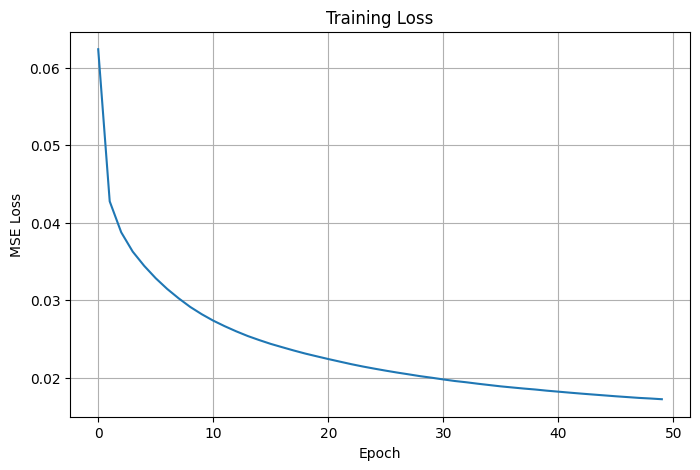

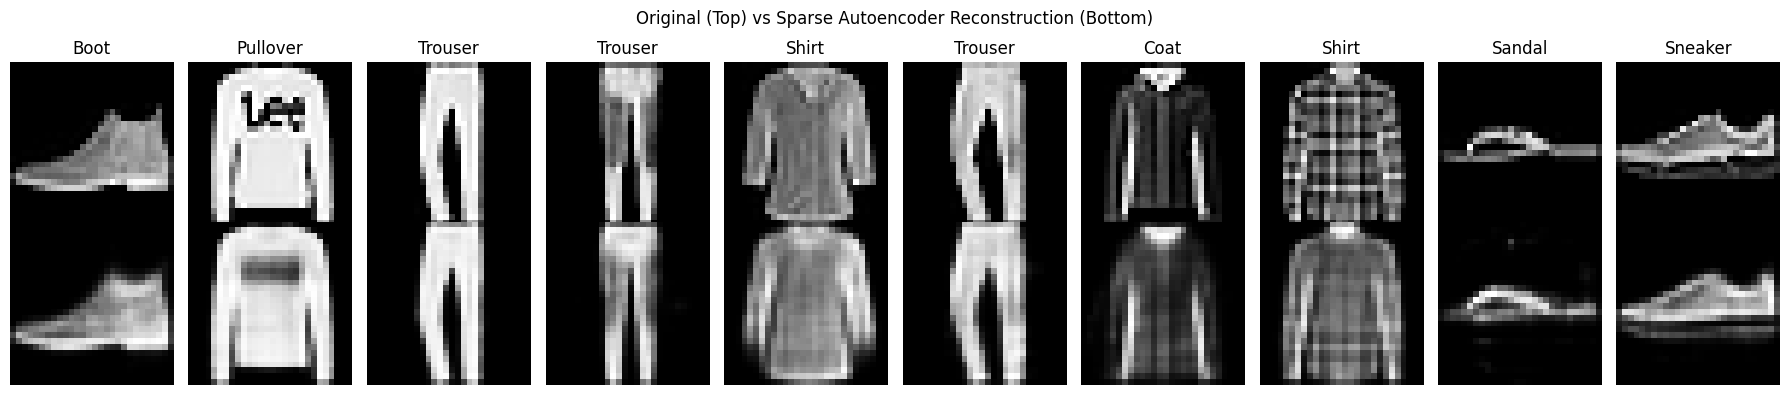

Fraction of near-zero latent activations: 0.368
Average active units per sample: 40.4 / 64


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

def reconstruct_sparse(images, params):
    reconstructed, _ = sparse_ae_forward(images, params)
    return reconstructed

sample_images = X_test[:10]
reconstructed_images = reconstruct_sparse(sample_images, params)

fashion_labels = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Boot"]
n = 10
plt.figure(figsize=(18,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap="gray")
    plt.title(fashion_labels[y_test[i]])
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
plt.suptitle("Original (Top) vs Sparse Autoencoder Reconstruction (Bottom)")
plt.tight_layout()
plt.show()

# check actual sparsity achieved: what fraction of latent units are ~0 per sample
_, cache_check = sparse_ae_forward(X_test[:1000], params)
latent_activations = cache_check["A2"]
sparsity_fraction = np.mean(latent_activations < 0.01)
print(f"Fraction of near-zero latent activations: {sparsity_fraction:.3f}")
print(f"Average active units per sample: {(latent_activations > 0.01).sum(axis=1).mean():.1f} / {latent_activations.shape[1]}")